In [1]:
# Imports:
import numpy as np
import os
import pandas as pd
from lerobot.datasets.lerobot_dataset import LeRobotDataset
import matplotlib.pyplot as plt

## 1. Read everything using standard packages:

In [2]:
folder_path = os.getcwd()
file_path = '/so101_policy_robustness/meta'
full_path = folder_path + file_path
print(os.listdir(folder_path + file_path))
df = pd.read_json(full_path + '/' + 'info.json')
# print(df)
df2 = pd.read_parquet(full_path + '/' + 'tasks.parquet')
# print(df2)
df3 = pd.read_parquet(full_path + '/' + 'episodes/chunk-000/file-000.parquet')
# print(df3)

['.DS_Store', 'episodes', 'info.json', 'tasks.parquet', 'stats.json']


## 2. Read everything with LeRobot package:

## 2.1. Load data using LeRobot package:

In [3]:
folder_path = os.getcwd()
file_path = '/so101_policy_robustness'
ds =  LeRobotDataset(folder_path + file_path)
ds

objc[21224]: Class AVFFrameReceiver is implemented in both /Users/tamara/miniforge3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x14d5d43a8) and /Users/tamara/miniforge3/envs/lerobot/lib/libavdevice.62.3.102.dylib (0x1564007a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[21224]: Class AVFAudioReceiver is implemented in both /Users/tamara/miniforge3/envs/lerobot/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x14d5d43f8) and /Users/tamara/miniforge3/envs/lerobot/lib/libavdevice.62.3.102.dylib (0x1564007f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


LeRobotDataset({
    Repository ID: '/Users/tamara/Google Drive/act-diffusion-vla-so101/so101_policy_robustness',
    Number of selected episodes: '50',
    Number of selected samples: '26689',
    Features: '['action', 'observation.state', 'observation.images.front', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})

## 2.2 Schema features:

In [4]:
ds.meta.features

{'action': {'dtype': 'float32',
  'names': ['shoulder_pan.pos',
   'shoulder_lift.pos',
   'elbow_flex.pos',
   'wrist_flex.pos',
   'wrist_roll.pos',
   'gripper.pos'],
  'shape': (6,)},
 'observation.state': {'dtype': 'float32',
  'names': ['shoulder_pan.pos',
   'shoulder_lift.pos',
   'elbow_flex.pos',
   'wrist_flex.pos',
   'wrist_roll.pos',
   'gripper.pos'],
  'shape': (6,)},
 'observation.images.front': {'dtype': 'video',
  'shape': (480, 640, 3),
  'names': ['height', 'width', 'channels'],
  'info': {'is_depth_map': False,
   'video.height': 480,
   'video.width': 640,
   'video.codec': 'av1',
   'video.pix_fmt': 'yuv420p',
   'video.fps': 30,
   'video.channels': 3,
   'has_audio': False,
   'video.g': 2,
   'video.crf': 30,
   'video.preset': 12,
   'video.fast_decode': 0,
   'video.video_backend': 'pyav',
   'video.extra_options': {}}},
 'timestamp': {'dtype': 'float32', 'shape': (1,), 'names': None},
 'frame_index': {'dtype': 'int64', 'shape': (1,), 'names': None},
 'epis

## 2.3. ds is loaded per frame

In [5]:
len(ds)

26689

## 2.4. Print one frame:

In [6]:
frame = ds[10000]
for k,v in frame.items():
    try:
        print(f"{k:35s} {type(v).__name__:10s} {tuple(v.shape)} {v.dtype}")
    except AttributeError:
        print(f"{k:35s} {v}")

observation.images.front            Tensor     (3, 480, 640) torch.float32
action                              Tensor     (6,) torch.float32
observation.state                   Tensor     (6,) torch.float32
timestamp                           Tensor     () torch.float32
frame_index                         Tensor     () torch.int64
episode_index                       Tensor     () torch.int64
index                               Tensor     () torch.int64
task_index                          Tensor     () torch.int64
task                                Pick up the pink block and place it in the plate


In [7]:
list(frame.items())[0]

('observation.images.front',
 tensor([[[0.3137, 0.3137, 0.3137,  ..., 0.4471, 0.4471, 0.4471],
          [0.3137, 0.3137, 0.3137,  ..., 0.4431, 0.4431, 0.4431],
          [0.3137, 0.3137, 0.3137,  ..., 0.4392, 0.4392, 0.4392],
          ...,
          [0.0549, 0.0549, 0.0549,  ..., 0.5843, 0.5765, 0.5765],
          [0.0549, 0.0549, 0.0549,  ..., 0.5843, 0.5765, 0.5725],
          [0.0549, 0.0549, 0.0549,  ..., 0.5882, 0.5765, 0.5725]],
 
         [[0.4235, 0.4235, 0.4235,  ..., 0.5647, 0.5647, 0.5647],
          [0.4235, 0.4235, 0.4235,  ..., 0.5569, 0.5569, 0.5569],
          [0.4235, 0.4235, 0.4235,  ..., 0.5529, 0.5529, 0.5529],
          ...,
          [0.0510, 0.0510, 0.0510,  ..., 0.5608, 0.5647, 0.5647],
          [0.0510, 0.0510, 0.0510,  ..., 0.5608, 0.5647, 0.5608],
          [0.0510, 0.0510, 0.0510,  ..., 0.5686, 0.5647, 0.5608]],
 
         [[0.5020, 0.5020, 0.5020,  ..., 0.5686, 0.5686, 0.5686],
          [0.5020, 0.5020, 0.5020,  ..., 0.5647, 0.5647, 0.5647],
          [

In [8]:
print(frame['observation.state'])
print(frame['action'])

tensor([  12.3956, -101.2747,   91.5165,   61.1868,    0.3956,    1.1111])
tensor([  12.2637, -101.2308,   89.4945,   58.9451,    0.4835,    1.0888])


In [9]:
print(frame["episode_index"])    # which episode this frame belongs to
print(frame["frame_index"])      # position within that episode (resets to 0 each episode)
print(frame["index"])            # global position (== 1000 here)

tensor(18)
tensor(92)
tensor(10000)


## 2.5 Episode lengths + fps vs protocol:

In [10]:
print( "fps:", ds.fps)
lengths = [ds.meta.episodes[i]["length"] for i in range(ds.num_episodes)]
print("episdoes:", ds.num_episodes)
print("min/median/max length:", np.min(lengths), int(np.median(lengths)), np.max(lengths))
print("seconds:", np.min(lengths)/ds.fps, "to", np.max(lengths)/ds.fps)

fps: 30
episdoes: 50
min/median/max length: 455 526 655
seconds: 15.166666666666666 to 21.833333333333332


## 3. How much time should i cut for best dataset:

In [11]:
import torch

def motion_onset(ds, ep, thresh=2.0):   # thresh in joint units; tune by eyeballing one episode
    e = ds.meta.episodes[ep]
    start, end = e["dataset_from_index"], e["dataset_to_index"]
    a0 = ds[start]["action"]
    for i in range(start, end):
        if torch.max(torch.abs(ds[i]["action"] - a0)) > thresh:
            return i - start   # frame_index of first real motion
    return 0

def motion_idle(ds, ep, thresh=2.0):   # thresh in joint units; tune by eyeballing one episode
    e = ds.meta.episodes[ep]
    start, end = e["dataset_from_index"], e["dataset_to_index"]
    a_last = ds[end-1]["action"]
    for i in range(end-2, start-1, -1):
        if torch.max(torch.abs(ds[i]["action"] - a_last)) > thresh:
            return end - 1 - i   # number of frames from the end
    return 0

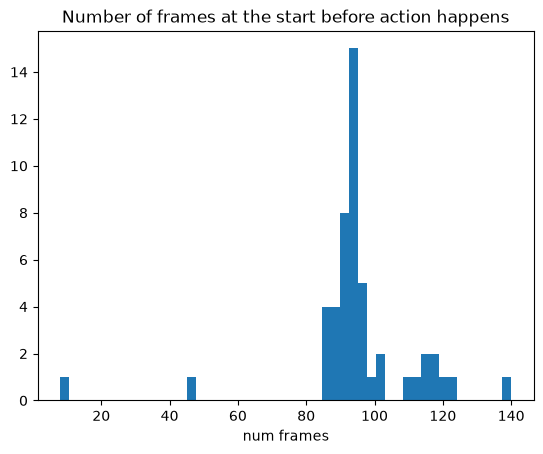

In [23]:
num_episodes = ds.num_episodes
head_result = np.zeros(num_episodes)
for i in range(num_episodes):
    head_result[i] = motion_onset(ds,i)

plt.hist(head_result, bins = num_episodes)
plt.xlabel('num frames')
plt.title('Number of frames at the start before action happens')
plt.show()

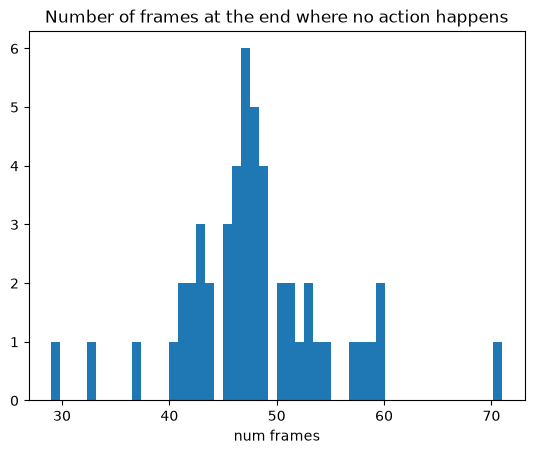

In [24]:
num_episodes = ds.num_episodes
tail_result = np.zeros(num_episodes)
for i in range(num_episodes):
    tail_result[i] = motion_idle(ds,i)

plt.hist(tail_result, bins = num_episodes)
plt.xlabel('num frames')
plt.title('Number of frames at the end where no action happens')
plt.show()

In [14]:
import json

trim = {
    int(ep): {"head": int(head_result[ep]), "tail": int(tail_result[ep])}
    for ep in range(ds.num_episodes)
}
with open("trim_frames.json", "w") as f:
    json.dump(trim, f, indent=2)

In [25]:
e = ds.meta.episodes[12]
start, end = e["dataset_from_index"], e["dataset_to_index"]
a_last = ds[end-1]["action"]
print(a_last)

tensor([  14.7253, -101.1429,   93.6264,   58.9451,   -1.8022,    1.0888])


### Let's fix episode 12 and 22 (starting the counting from 0) as they register fake movement at frame 10 and 46, but actual movement happens later (confirmed in video and follower/leader states):

In [26]:
import json

with open("trim_frames.json") as f:
    trims = json.load(f)

trims["13"]["head"] = 80   # <- your read-off value
trims["23"]["head"] = 80   # <- your read-off value

with open("trim_frames.json", "w") as f:
    json.dump(trims, f, indent=2)